# Stats of features:
She said, she said - The Beatles


## 5 min labeling (ictal vs. pre-ictal)

### 1. Load df with features: Ictal vs. preictal 5min

In [4]:
import pandas as pd

df_feat_ictalVspreictal_5min = pd.read_pickle("/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/XB47Y/Feature_ext/Part2_features/df_features_ictal_Vs_Preictal.pkl")

print(df_feat_ictalVspreictal_5min.head())


                   file_name  window_id  start_sample  end_sample          fs  \
0  XB47Y_41_preproc_full.npz       1254       2595780     2597850  207.031055   
1  XB47Y_41_preproc_full.npz       1255       2597850     2599920  207.031055   
2  XB47Y_41_preproc_full.npz       1256       2599920     2601990  207.031055   
3  XB47Y_41_preproc_full.npz       1257       2601990     2604060  207.031055   
4  XB47Y_41_preproc_full.npz       1258       2604060     2606130  207.031055   

   n_channels  window_sec                seizure_onsets  \
0           2          10  [2019-10-31 23:25:08.153000]   
1           2          10  [2019-10-31 23:25:08.153000]   
2           2          10  [2019-10-31 23:25:08.153000]   
3           2          10  [2019-10-31 23:25:08.153000]   
4           2          10  [2019-10-31 23:25:08.153000]   

              window_start_time               window_end_time  ...  \
0 2019-10-31 23:15:03.118999591 2019-10-31 23:15:13.117499590  ...   
1 2019-10-31 23:15

In [13]:
  #  "interictal": 0,
  #  "preictal": 1,
  #  "seizure": 2
# Group 1: preictal windows
group_1_PREICTAL = df_feat_ictalVspreictal_5min[df_feat_ictalVspreictal_5min["class_label"] == 1].copy()

# Group 2: seizure windows
group_2_SEIZURE = df_feat_ictalVspreictal_5min[df_feat_ictalVspreictal_5min["class_label"] == 2].copy()

print("Shape of group 1 preictal:", group_1_PREICTAL.shape)
print("Shape of group 2 seizure:", group_2_SEIZURE.shape)

#Shape of group 0: (1047, 41)
#Shape of group 1: (1102, 41)

Shape of group 1 preictal: (1047, 41)
Shape of group 2 seizure: (1102, 41)


In [8]:
df_feat_ictalVspreictal_5min["peak_frequency_EEG_SQ_D_SQ_C"].describe()

count    2149.000000
mean        1.367818
std         2.963405
min         0.500075
25%         1.000150
50%         1.000150
75%         1.000150
max        39.505926
Name: peak_frequency_EEG_SQ_D_SQ_C, dtype: float64

In [14]:
group_1_PREICTAL.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1254,2595780,2597850,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:03.118999591,2019-10-31 23:15:13.117499590,...,0.003656,0.034655,0.018155,1.00015,0.160633,0.008688,0.008652,0.033698,0.021094,1.00015
1,XB47Y_41_preproc_full.npz,1255,2597850,2599920,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:13.117499590,2019-10-31 23:15:23.115999590,...,0.034949,0.066192,0.024481,1.00015,1.160761,0.058562,0.066291,0.911522,0.171770,1.00015
2,XB47Y_41_preproc_full.npz,1256,2599920,2601990,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:23.115999590,2019-10-31 23:15:33.114499590,...,0.001955,0.038650,0.011128,1.00015,0.086239,0.006419,0.004891,0.055154,0.029888,1.00015
3,XB47Y_41_preproc_full.npz,1257,2601990,2604060,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:33.114499590,2019-10-31 23:15:43.112999590,...,0.002152,0.039139,0.012537,1.00015,0.074514,0.006131,0.007192,0.052075,0.028502,1.00015
4,XB47Y_41_preproc_full.npz,1258,2604060,2606130,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:43.112999590,2019-10-31 23:15:53.111499589,...,0.002427,0.062461,0.022991,1.00015,0.032069,0.003982,0.010966,0.093744,0.045717,1.00015


In [11]:
import numpy as np

# Select only numeric columns
numeric_cols = df_feat_ictalVspreictal_5min.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)
print("Number of numeric columns:", len(numeric_cols))

Numeric columns:
['window_id', 'start_sample', 'end_sample', 'fs', 'n_channels', 'window_sec', 'class_label', 'mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of numeric columns: 35


In [12]:
# Numeric columns that are metadata or not real signal features
exclude_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "class_label"
]

# Keep only true numeric feature columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Feature columns:")
print(feature_cols)
print("Number of feature columns:", len(feature_cols))

Feature columns:
['window_sec', 'mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of feature columns: 29


In [19]:
feature_cols

['window_sec',
 'mean_EEG_SQ_D_SQ_C',
 'std_EEG_SQ_D_SQ_C',
 'var_EEG_SQ_D_SQ_C',
 'rms_EEG_SQ_D_SQ_C',
 'ptp_EEG_SQ_D_SQ_C',
 'line_length_EEG_SQ_D_SQ_C',
 'skew_EEG_SQ_D_SQ_C',
 'kurtosis_EEG_SQ_D_SQ_C',
 'mean_EEG_SQ_P_SQ_C',
 'std_EEG_SQ_P_SQ_C',
 'var_EEG_SQ_P_SQ_C',
 'rms_EEG_SQ_P_SQ_C',
 'ptp_EEG_SQ_P_SQ_C',
 'line_length_EEG_SQ_P_SQ_C',
 'skew_EEG_SQ_P_SQ_C',
 'kurtosis_EEG_SQ_P_SQ_C',
 'delta_power_EEG_SQ_D_SQ_C',
 'theta_power_EEG_SQ_D_SQ_C',
 'alpha_power_EEG_SQ_D_SQ_C',
 'beta_power_EEG_SQ_D_SQ_C',
 'gamma_power_EEG_SQ_D_SQ_C',
 'peak_frequency_EEG_SQ_D_SQ_C',
 'delta_power_EEG_SQ_P_SQ_C',
 'theta_power_EEG_SQ_P_SQ_C',
 'alpha_power_EEG_SQ_P_SQ_C',
 'beta_power_EEG_SQ_P_SQ_C',
 'gamma_power_EEG_SQ_P_SQ_C',
 'peak_frequency_EEG_SQ_P_SQ_C']

### 2. Box-plots + mann whitney:

In [15]:
# TEST with only one feature
feat_ch1 = "mean_EEG_SQ_D_SQ_C"
feat_ch2 = "mean_EEG_SQ_P_SQ_C"

df_boxplot_PREICTAL_test_MEAN = pd.DataFrame({
    "value": pd.concat([group_1_PREICTAL[feat_ch1], group_1_PREICTAL[feat_ch2]], axis=0),
    "channel": ["ch1"] * len(group_1_PREICTAL) + ["ch2"] * len(group_1_PREICTAL),
    "class": pd.concat([group_1_PREICTAL["class_label"], group_1_PREICTAL["class_label"]], axis=0)
})

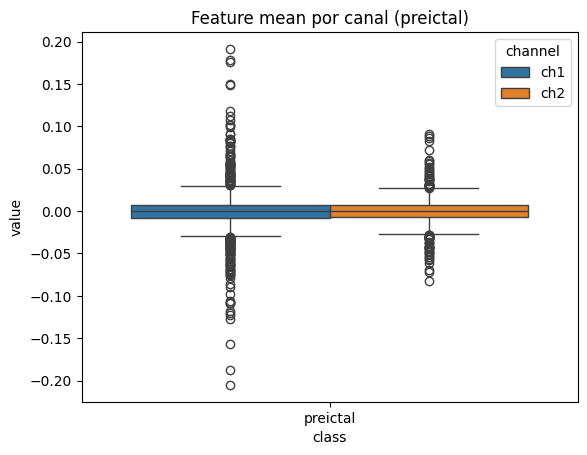

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_boxplot_PREICTAL_test_MEAN,
    x="class",
    y="value",
    hue="channel"
)

plt.xticks([0], ["preictal"])  
plt.title("Feature mean per channel (preictal)")
plt.show()